# Classification Comparison: Arousal Pipeline vs Rule-Based (class_pl_gen)

Compares two classification approaches on the same data:

| | **Arousal Pipeline** (`music_class_test.ipynb`) | **Rule-Based** (`class_pl_gen.ipynb`) |
|---|---|---|
| Method | Weighted arousal score on MinMax-scaled features | Hard threshold filters on raw features |
| Calm | `arousal < 0.35 AND valence >= 0.25` | tempo 50-90, energy <0.50, acousticness >0, valence 0.35-1.0, loudness -20 to -5, danceability >0.50 |
| Energy | `arousal > 0.65` | tempo 120-200, energy >0.60, danceability >0.50, valence >0.45, loudness >-12 |
| Other | Everything else | Everything else |
| Pre-filter | speechiness >0.66, liveness >0.80 | speechiness >0.70, liveness >0.80 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

PROJECT_ROOT = Path("..").resolve()
PARTICIPANT = "kokosnoot"

print("Imports OK")

Imports OK


## 1. Load data and reproduce both classifications on the same DataFrame

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  Load the arousal pipeline output (already classified)
# ══════════════════════════════════════════════════════════════════════════════

arousal_csv = PROJECT_ROOT / "data" / "playlists" / PARTICIPANT / "playlist_ml" / "classified_songs.csv"
df = pd.read_csv(arousal_csv)
print(f"Loaded {len(df)} songs from arousal pipeline output")

# Rename arousal pipeline class for clarity
df.rename(columns={"class": "arousal_class"}, inplace=True)

# ══════════════════════════════════════════════════════════════════════════════
#  Reproduce class_pl_gen.ipynb rule-based classification on the same data
# ══════════════════════════════════════════════════════════════════════════════
# Parameters copied exactly from class_pl_gen.ipynb cell 8:

CALM = dict(
    tempo_min=50, tempo_max=90,
    energy_max=0.50,
    acousticness_min=0.0,
    valence_min=0.35, valence_max=1.0,
    loudness_min=-20, loudness_max=-5,
    danceability_min=0.50,
    liveness_max=0.8,
)

ENERGY = dict(
    tempo_min=120, tempo_max=200,
    energy_min=0.60,
    danceability_min=0.50,
    valence_min=0.45,
    loudness_min=-12,
    liveness_max=0.8,
)


def classify_rule_based(row):
    """Reproduce class_pl_gen.ipynb filter logic as a per-row classifier."""
    # Calm check
    is_calm = (
        CALM["tempo_min"] <= row["tempo"] <= CALM["tempo_max"]
        and row["energy"] < CALM["energy_max"]
        and row.get("acousticness", 0) >= CALM["acousticness_min"]
        and CALM["valence_min"] <= row.get("valence", 0.5) <= CALM["valence_max"]
        and CALM["loudness_min"] <= row.get("loudness", -10) <= CALM["loudness_max"]
        and row.get("danceability", 0.5) >= CALM["danceability_min"]
        and row.get("liveness", 0) <= CALM["liveness_max"]
    )

    # Energy check
    is_energy = (
        ENERGY["tempo_min"] <= row["tempo"] <= ENERGY["tempo_max"]
        and row["energy"] >= ENERGY["energy_min"]
        and row.get("danceability", 0.5) >= ENERGY["danceability_min"]
        and row.get("valence", 0.5) >= ENERGY["valence_min"]
        and row.get("loudness", -10) >= ENERGY["loudness_min"]
        and row.get("liveness", 0) <= ENERGY["liveness_max"]
    )

    # Energy wins ties (same as class_pl_gen.ipynb)
    if is_energy:
        return "energy"
    elif is_calm:
        return "calm"
    else:
        return "other"


df["rule_class"] = df.apply(classify_rule_based, axis=1)

print("\nArousal pipeline class distribution:")
print(df["arousal_class"].value_counts().to_string())
print("\nRule-based (class_pl_gen) class distribution:")
print(df["rule_class"].value_counts().to_string())

Loaded 389 songs from arousal pipeline output

Arousal pipeline class distribution:
arousal_class
other     255
energy    106
calm       28

Rule-based (class_pl_gen) class distribution:
rule_class
other     310
energy     75
calm        4


---
## 2. Overall Agreement

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONTINGENCY TABLE — full cross-tabulation
# ══════════════════════════════════════════════════════════════════════════════

ct = pd.crosstab(df["arousal_class"], df["rule_class"], margins=True,
                 rownames=["Arousal Pipeline"], colnames=["Rule-Based (class_pl_gen)"])
print("Contingency table:")
display(ct)

# Overall agreement
agree = (df["arousal_class"] == df["rule_class"]).sum()
total = len(df)
print(f"\nOverall agreement: {agree} / {total} songs ({agree/total*100:.1f}%)")
print(f"Disagreements:     {total - agree} songs ({(total-agree)/total*100:.1f}%)")

Contingency table:


Rule-Based (class_pl_gen),calm,energy,other,All
Arousal Pipeline,,,,
calm,4,0,24,28
energy,0,33,73,106
other,0,42,213,255
All,4,75,310,389



Overall agreement: 250 / 389 songs (64.3%)
Disagreements:     139 songs (35.7%)


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  PER-CLASS AGREEMENT STATS
# ══════════════════════════════════════════════════════════════════════════════
# For each class: how many songs does each method assign, and where do they
# agree or disagree?

CLASS_COLORS = {"calm": "#2196F3", "energy": "#F44336", "other": "#9E9E9E"}

for cls in ["calm", "energy", "other"]:
    arousal_set = set(df[df["arousal_class"] == cls].index)
    rule_set = set(df[df["rule_class"] == cls].index)

    both = arousal_set & rule_set
    only_arousal = arousal_set - rule_set
    only_rule = rule_set - arousal_set

    print(f"\n{'═'*60}")
    print(f"  {cls.upper()}")
    print(f"{'═'*60}")
    print(f"  Arousal pipeline: {len(arousal_set):>5} songs")
    print(f"  Rule-based:       {len(rule_set):>5} songs")
    print(f"  Both agree:       {len(both):>5} songs")
    print(f"  Only arousal:     {len(only_arousal):>5} (arousal says {cls}, rules say something else)")
    print(f"  Only rule-based:  {len(only_rule):>5} (rules say {cls}, arousal says something else)")

    if len(arousal_set) > 0:
        recall_arousal = len(both) / len(arousal_set)
        print(f"  Rule-based covers {recall_arousal:.1%} of arousal's {cls} songs")
    if len(rule_set) > 0:
        recall_rule = len(both) / len(rule_set)
        print(f"  Arousal covers    {recall_rule:.1%} of rule-based's {cls} songs")


════════════════════════════════════════════════════════════
  CALM
════════════════════════════════════════════════════════════
  Arousal pipeline:    28 songs
  Rule-based:           4 songs
  Both agree:           4 songs
  Only arousal:        24 (arousal says calm, rules say something else)
  Only rule-based:      0 (rules say calm, arousal says something else)
  Rule-based covers 14.3% of arousal's calm songs
  Arousal covers    100.0% of rule-based's calm songs

════════════════════════════════════════════════════════════
  ENERGY
════════════════════════════════════════════════════════════
  Arousal pipeline:   106 songs
  Rule-based:          75 songs
  Both agree:          33 songs
  Only arousal:        73 (arousal says energy, rules say something else)
  Only rule-based:     42 (rules say energy, arousal says something else)
  Rule-based covers 31.1% of arousal's energy songs
  Arousal covers    44.0% of rule-based's energy songs

══════════════════════════════════════════

---
## 3. Disagreement Analysis — Where do the methods differ and why?

Total disagreements: 139 / 389 songs (35.7%)

Disagreement types (arousal -> rule-based):
──────────────────────────────────────────────────
  energy -> other         73 songs (18.8%)
  other -> energy         42 songs (10.8%)
  calm -> other           24 songs (6.2%)


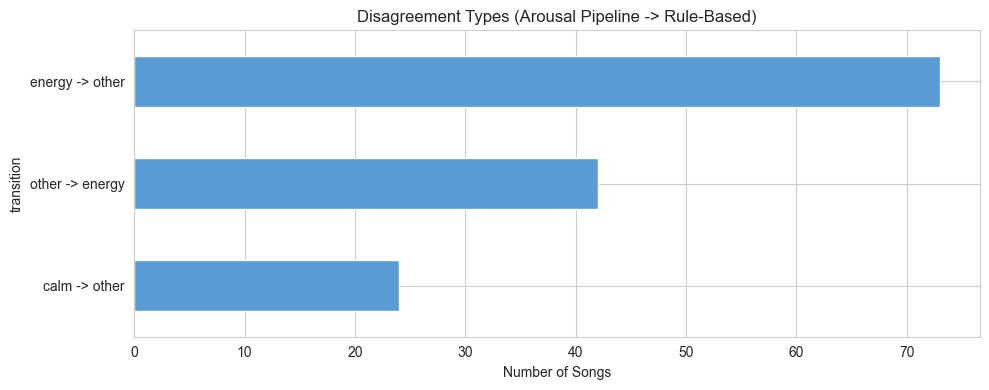

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  DISAGREEMENT BREAKDOWN — categorize every type of disagreement
# ══════════════════════════════════════════════════════════════════════════════
# Create a combined label for the transition type (e.g. "calm -> other")

disagree = df[df["arousal_class"] != df["rule_class"]].copy()
disagree["transition"] = disagree["arousal_class"] + " -> " + disagree["rule_class"]

print(f"Total disagreements: {len(disagree)} / {len(df)} songs ({len(disagree)/len(df)*100:.1f}%)\n")
print("Disagreement types (arousal -> rule-based):")
print(f"{'─'*50}")

transition_counts = disagree["transition"].value_counts()
for trans, count in transition_counts.items():
    pct = count / len(df) * 100
    print(f"  {trans:<20} {count:>5} songs ({pct:.1f}%)")

# Bar chart of transition types
fig, ax = plt.subplots(figsize=(10, 4))
transition_counts.plot(kind="barh", ax=ax, color="#5b9bd5", edgecolor="white")
ax.set_xlabel("Number of Songs")
ax.set_title("Disagreement Types (Arousal Pipeline -> Rule-Based)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  FEATURE PROFILES OF DISAGREEMENTS
# ══════════════════════════════════════════════════════════════════════════════
# For the most interesting disagreement types, show the mean features to
# understand WHY the two methods disagree.

features = ["tempo", "energy", "valence", "loudness", "acousticness", "danceability", "speechiness"]

# Only show transitions with at least 5 songs
top_transitions = transition_counts[transition_counts >= 5].index.tolist()

for trans in top_transitions:
    subset = disagree[disagree["transition"] == trans]
    print(f"\n{'═'*65}")
    print(f"  {trans} — {len(subset)} songs")
    print(f"{'═'*65}")
    print(f"  Mean features:")
    for feat in features:
        if feat in subset.columns:
            print(f"    {feat:<18} {subset[feat].mean():>8.3f}  (std={subset[feat].std():.3f})")
    if "arousal_score" in subset.columns:
        print(f"    {'arousal_score':<18} {subset['arousal_score'].mean():>8.3f}  (std={subset['arousal_score'].std():.3f})")


═════════════════════════════════════════════════════════════════
  energy -> other — 73 songs
═════════════════════════════════════════════════════════════════
  Mean features:
    tempo               152.537  (std=21.070)
    energy                0.917  (std=0.043)
    valence               0.493  (std=0.206)
    loudness             -4.317  (std=1.051)
    acousticness          0.011  (std=0.027)
    danceability          0.401  (std=0.092)
    speechiness           0.072  (std=0.032)
    arousal_score         0.711  (std=0.040)

═════════════════════════════════════════════════════════════════
  other -> energy — 42 songs
═════════════════════════════════════════════════════════════════
  Mean features:
    tempo               132.304  (std=10.172)
    energy                0.751  (std=0.076)
    valence               0.688  (std=0.144)
    loudness             -6.471  (std=1.725)
    acousticness          0.121  (std=0.153)
    danceability          0.625  (std=0.093)
    speech

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
#  SAMPLE DISAGREEMENTS — concrete examples
# ══════════════════════════════════════════════════════════════════════════════
# Show actual song names for the most common disagreement types.

show_cols = ["name", "artists", "tempo", "energy", "valence", "loudness",
             "danceability", "arousal_score", "arousal_class", "rule_class"]
show_cols = [c for c in show_cols if c in df.columns]

for trans in top_transitions[:4]:
    subset = disagree[disagree["transition"] == trans]
    n_show = min(8, len(subset))
    print(f"\n{'═'*70}")
    print(f"  {trans} — {n_show} samples (of {len(subset)})")
    print(f"{'═'*70}")
    display(subset[show_cols].sample(n_show, random_state=42))


══════════════════════════════════════════════════════════════════════
  energy -> other — 8 samples (of 73)
══════════════════════════════════════════════════════════════════════


,name,artists,tempo,energy,valence,loudness,danceability,arousal_score,arousal_class,rule_class
27,Every You Every Me,Placebo,133.135,0.923,0.165,-7.547,0.478,0.652304,energy,other
371,Discount De Kooning (Last One Standing),The Vaccines,151.992,0.826,0.564,-3.919,0.409,0.679127,energy,other
85,I Always Knew,The Vaccines,150.097,0.872,0.393,-2.530,0.393,0.705690,energy,other
13,Heartbreak Kid,The Vaccines,162.016,0.911,0.556,-3.370,0.383,0.734891,energy,other
112,Time is Running Out,Muse,118.005,0.892,0.317,-3.212,0.544,0.653721,energy,other
386,Wolf Pack,The Vaccines,116.990,0.924,0.807,-4.504,0.556,0.652860,energy,other
46,Carrion,Parkway Drive,155.212,0.969,0.428,-4.070,0.228,0.726879,energy,other
144,Never Fight A Man With A Perm,IDLES,155.967,0.946,0.223,-4.876,0.255,0.714600,energy,other



══════════════════════════════════════════════════════════════════════
  other -> energy — 8 samples (of 42)
══════════════════════════════════════════════════════════════════════


,name,artists,tempo,energy,valence,loudness,danceability,arousal_score,arousal_class,rule_class
221,Cut Here - Acoustic Version,The Cure,134.995,0.645,0.786,-7.978,0.787,0.531216,other,energy
158,Sorrow,The National,122.278,0.740,0.521,-8.830,0.550,0.539989,other,energy
83,You Know Me Too Well,Nothing But Thieves,135.931,0.688,0.773,-5.042,0.605,0.602146,other,energy
223,The Ballad,Blur,133.997,0.617,0.585,-7.434,0.605,0.513974,other,energy
66,Smokers Outside The Hospital Doors,Editors,122.997,0.674,0.554,-3.792,0.529,0.577865,other,energy
367,Blow,Blossoms,120.014,0.824,0.671,-4.694,0.502,0.616646,other,energy
204,Gold Dust Woman - 2004 Remaster,Fleetwood Mac,123.180,0.608,0.674,-9.335,0.666,0.485504,other,energy
249,Stand On The Horizon,Franz Ferdinand,123.373,0.824,0.564,-4.422,0.670,0.626385,other,energy



══════════════════════════════════════════════════════════════════════
  calm -> other — 8 samples (of 24)
══════════════════════════════════════════════════════════════════════


,name,artists,tempo,energy,valence,loudness,danceability,arousal_score,arousal_class,rule_class
185,Down the Highway,Bob Dylan,137.679,0.138,0.416,-21.116,0.473,0.187310,calm,other
194,I Shall Be Free,Bob Dylan,100.552,0.314,0.798,-12.880,0.640,0.241799,calm,other
38,I See Fire,Ed Sheeran,152.122,0.176,0.296,-11.692,0.591,0.322518,calm,other
232,The Swan,Blur,74.989,0.400,0.394,-9.210,0.440,0.260064,calm,other
188,"Don't Think Twice, It's All Right",Bob Dylan,110.535,0.243,0.468,-17.085,0.600,0.192735,calm,other
186,Bob Dylan's Blues,Bob Dylan,124.594,0.179,0.851,-18.796,0.533,0.188320,calm,other
190,Oxford Town,Bob Dylan,106.730,0.218,0.632,-17.302,0.658,0.179404,calm,other
40,Blue Ridge Mountains,Fleet Foxes,97.856,0.446,0.272,-7.823,0.524,0.339316,calm,other


---
## 4. Visual Comparison

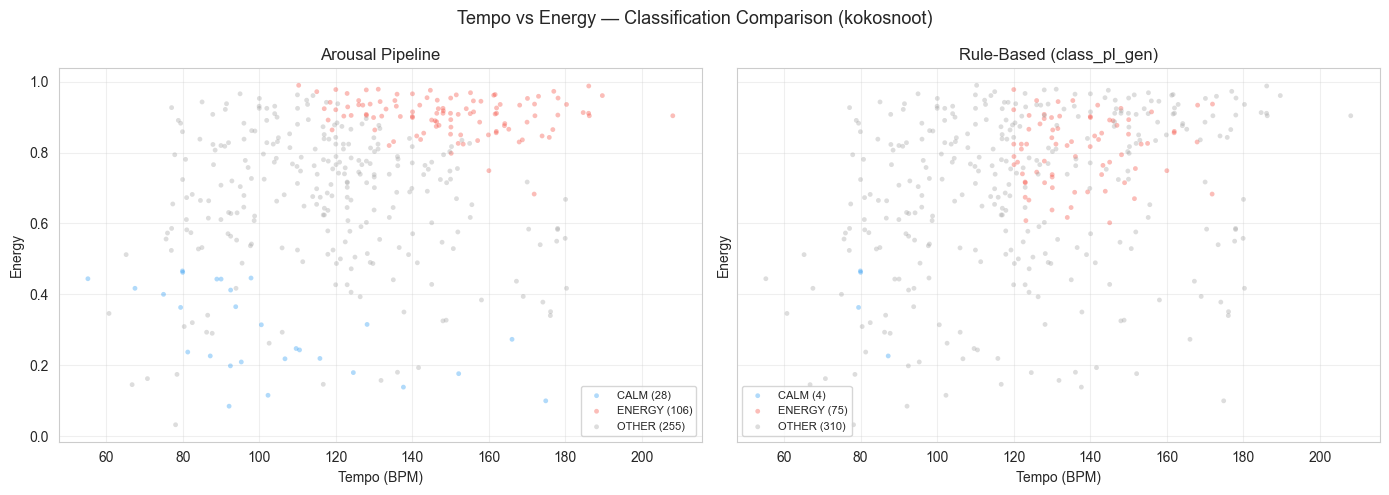

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
#  SIDE-BY-SIDE TEMPO vs ENERGY scatter plots
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, (col, title) in zip(axes, [
    ("arousal_class", "Arousal Pipeline"),
    ("rule_class", "Rule-Based (class_pl_gen)")
]):
    for cls, color in CLASS_COLORS.items():
        mask = df[col] == cls
        ax.scatter(df.loc[mask, "tempo"], df.loc[mask, "energy"],
                   c=color, label=f"{cls.upper()} ({mask.sum()})",
                   alpha=0.35, s=12, edgecolors="none")
    ax.set_xlabel("Tempo (BPM)")
    ax.set_ylabel("Energy")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Tempo vs Energy — Classification Comparison ({PARTICIPANT})", fontsize=13)
plt.tight_layout()
plt.show()

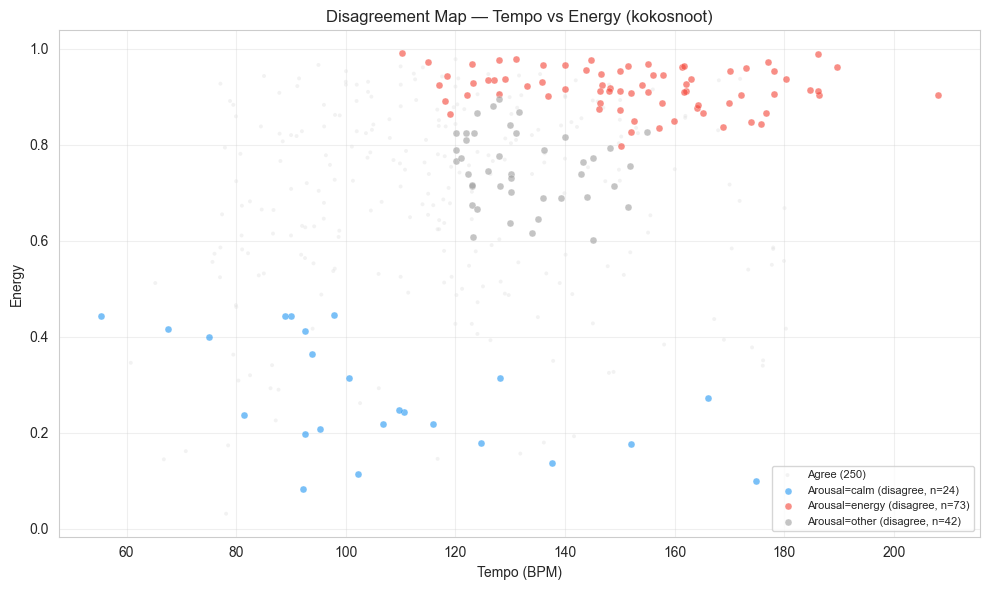

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
#  DISAGREEMENT MAP — highlight only the songs where methods disagree
# ══════════════════════════════════════════════════════════════════════════════

agree_mask = df["arousal_class"] == df["rule_class"]

fig, ax = plt.subplots(figsize=(10, 6))

# Background: agreements in light gray
ax.scatter(df.loc[agree_mask, "tempo"], df.loc[agree_mask, "energy"],
           c="#e0e0e0", s=8, alpha=0.4, edgecolors="none", label=f"Agree ({agree_mask.sum()})")

# Foreground: disagreements colored by arousal class
for cls, color in CLASS_COLORS.items():
    mask = (~agree_mask) & (df["arousal_class"] == cls)
    if mask.sum() > 0:
        ax.scatter(df.loc[mask, "tempo"], df.loc[mask, "energy"],
                   c=color, s=25, alpha=0.6, edgecolors="white", linewidths=0.3,
                   label=f"Arousal={cls} (disagree, n={mask.sum()})")

ax.set_xlabel("Tempo (BPM)")
ax.set_ylabel("Energy")
ax.set_title(f"Disagreement Map — Tempo vs Energy ({PARTICIPANT})")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

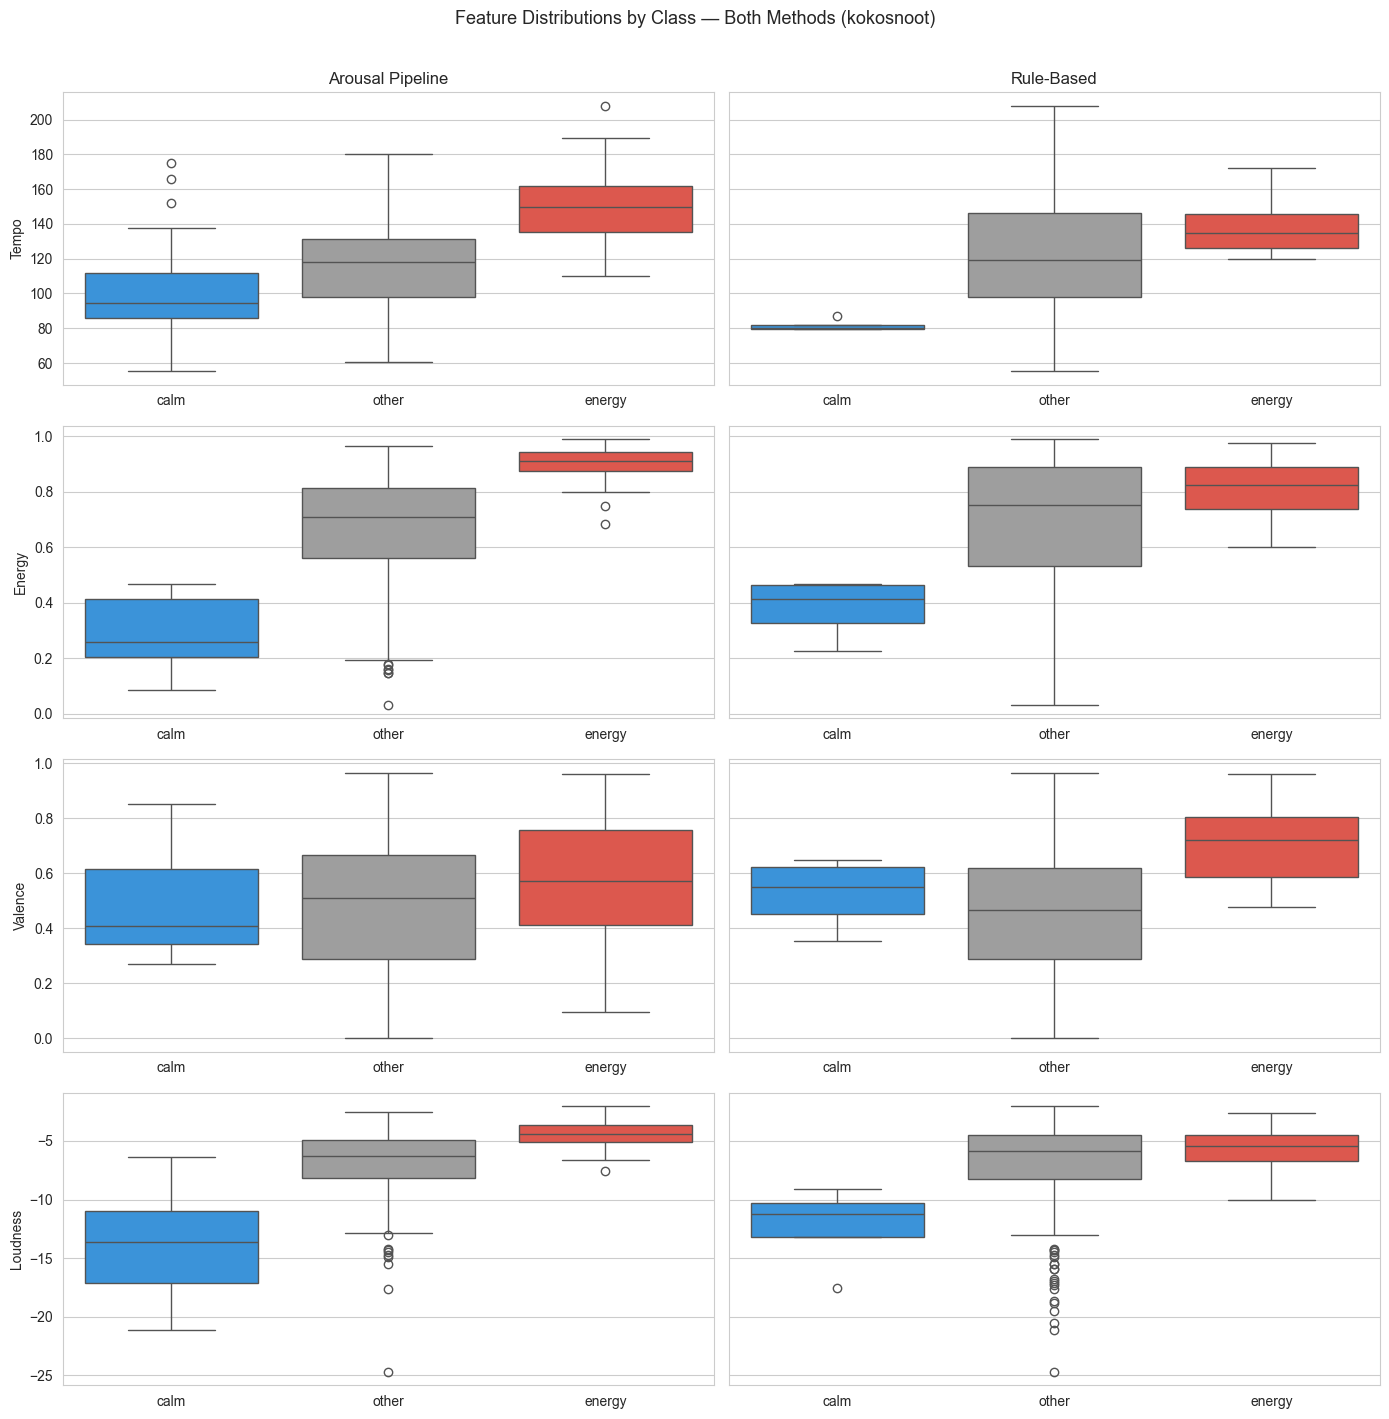

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
#  FEATURE BOXPLOTS — per method side by side
# ══════════════════════════════════════════════════════════════════════════════

compare_features = ["tempo", "energy", "valence", "loudness"]
order = ["calm", "other", "energy"]
palette = {c: CLASS_COLORS[c] for c in order}

fig, axes = plt.subplots(len(compare_features), 2, figsize=(14, 3.5 * len(compare_features)),
                         sharex="row", sharey="row")

for row, feat in enumerate(compare_features):
    for col, (cls_col, title) in enumerate([
        ("arousal_class", "Arousal Pipeline"),
        ("rule_class", "Rule-Based")
    ]):
        ax = axes[row][col]
        sns.boxplot(data=df, x=cls_col, y=feat, hue=cls_col, order=order,
                    palette=palette, legend=False, ax=ax)
        ax.set_title(f"{title}" if row == 0 else "")
        ax.set_xlabel("")
        if col == 0:
            ax.set_ylabel(feat.title())
        else:
            ax.set_ylabel("")

plt.suptitle(f"Feature Distributions by Class — Both Methods ({PARTICIPANT})", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Root Cause Analysis — Why do the methods disagree?

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
#  ROOT CAUSE: Which feature thresholds cause the most disagreements?
# ══════════════════════════════════════════════════════════════════════════════
# For each disagreeing song, identify which rule-based threshold it fails
# that the arousal pipeline doesn't enforce (or vice versa).

# Key structural differences between the two methods:
differences = {
    "Calm tempo range": {
        "arousal": "No hard tempo cutoff (uses weighted score)",
        "rules":   "tempo must be 50-90 BPM",
    },
    "Energy tempo floor": {
        "arousal": "No hard tempo cutoff (uses weighted score)",
        "rules":   "tempo must be >= 120 BPM",
    },
    "Calm energy cap": {
        "arousal": "Energy contributes to arousal score (weighted 0.35)",
        "rules":   "energy must be < 0.50",
    },
    "Danceability filter": {
        "arousal": "Danceability has tiny weight (0.05) in arousal score",
        "rules":   "danceability >= 0.50 required for both calm and energy",
    },
    "Loudness filter": {
        "arousal": "Loudness contributes to arousal score (weighted 0.20)",
        "rules":   "Calm: -20 to -5 dB; Energy: >= -12 dB (hard cutoffs)",
    },
    "Valence filter": {
        "arousal": "Calm requires valence_norm >= 0.25 (very permissive)",
        "rules":   "Calm: valence 0.35-1.0; Energy: valence >= 0.45",
    },
}

print("Structural differences causing disagreements:")
print(f"{'═'*70}")
for name, diff in differences.items():
    print(f"\n  {name}")
    print(f"    Arousal: {diff['arousal']}")
    print(f"    Rules:   {diff['rules']}")

# ── Quantify: how many songs fall in "arousal calm" but fail rule-based calm thresholds?
arousal_calm = df[df["arousal_class"] == "calm"]
print(f"\n\n{'═'*70}")
print(f"Arousal CALM songs ({len(arousal_calm)}) that FAIL rule-based calm thresholds:")
print(f"{'─'*70}")

checks = {
    "tempo > 90 BPM":      (arousal_calm["tempo"] > 90).sum(),
    "energy >= 0.50":       (arousal_calm["energy"] >= 0.50).sum(),
    "danceability < 0.50":  (arousal_calm["danceability"] < 0.50).sum(),
    "valence < 0.35":       (arousal_calm["valence"] < 0.35).sum(),
    "loudness outside [-20,-5]": (
        (arousal_calm["loudness"] < -20) | (arousal_calm["loudness"] > -5)
    ).sum(),
}

for check, count in checks.items():
    pct = count / len(arousal_calm) * 100 if len(arousal_calm) > 0 else 0
    print(f"  {check:<30} {count:>4} songs ({pct:.1f}%)")

# Same for energy
arousal_energy = df[df["arousal_class"] == "energy"]
print(f"\nArousal ENERGY songs ({len(arousal_energy)}) that FAIL rule-based energy thresholds:")
print(f"{'─'*70}")

checks_e = {
    "tempo < 120 BPM":     (arousal_energy["tempo"] < 120).sum(),
    "energy < 0.60":        (arousal_energy["energy"] < 0.60).sum(),
    "danceability < 0.50":  (arousal_energy["danceability"] < 0.50).sum(),
    "valence < 0.45":       (arousal_energy["valence"] < 0.45).sum(),
    "loudness < -12 dB":    (arousal_energy["loudness"] < -12).sum(),
}

for check, count in checks_e.items():
    pct = count / len(arousal_energy) * 100 if len(arousal_energy) > 0 else 0
    print(f"  {check:<30} {count:>4} songs ({pct:.1f}%)")

Structural differences causing disagreements:
══════════════════════════════════════════════════════════════════════

  Calm tempo range
    Arousal: No hard tempo cutoff (uses weighted score)
    Rules:   tempo must be 50-90 BPM

  Energy tempo floor
    Arousal: No hard tempo cutoff (uses weighted score)
    Rules:   tempo must be >= 120 BPM

  Calm energy cap
    Arousal: Energy contributes to arousal score (weighted 0.35)
    Rules:   energy must be < 0.50

  Danceability filter
    Arousal: Danceability has tiny weight (0.05) in arousal score
    Rules:   danceability >= 0.50 required for both calm and energy

  Loudness filter
    Arousal: Loudness contributes to arousal score (weighted 0.20)
    Rules:   Calm: -20 to -5 dB; Energy: >= -12 dB (hard cutoffs)

  Valence filter
    Arousal: Calm requires valence_norm >= 0.25 (very permissive)
    Rules:   Calm: valence 0.35-1.0; Energy: valence >= 0.45


══════════════════════════════════════════════════════════════════════
Arousal 

---
## 6. Summary Statistics

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
#  SUMMARY TABLE — side-by-side comparison
# ══════════════════════════════════════════════════════════════════════════════

summary_data = []
for cls in ["calm", "energy", "other"]:
    a_sub = df[df["arousal_class"] == cls]
    r_sub = df[df["rule_class"] == cls]

    summary_data.append({
        "Class": cls.upper(),
        "Arousal Count": len(a_sub),
        "Rule Count": len(r_sub),
        "Arousal %": f"{len(a_sub)/len(df)*100:.1f}%",
        "Rule %": f"{len(r_sub)/len(df)*100:.1f}%",
        "Arousal Tempo (mean)": f"{a_sub['tempo'].mean():.0f}" if len(a_sub) > 0 else "-",
        "Rule Tempo (mean)": f"{r_sub['tempo'].mean():.0f}" if len(r_sub) > 0 else "-",
        "Arousal Energy (mean)": f"{a_sub['energy'].mean():.2f}" if len(a_sub) > 0 else "-",
        "Rule Energy (mean)": f"{r_sub['energy'].mean():.2f}" if len(r_sub) > 0 else "-",
    })

summary_df = pd.DataFrame(summary_data)
print("Side-by-side class comparison:")
display(summary_df)

# Final agreement stats
agree_total = (df["arousal_class"] == df["rule_class"]).sum()
cohen_classes = ["calm", "energy", "other"]

print(f"\n{'═'*50}")
print(f"  OVERALL AGREEMENT")
print(f"{'═'*50}")
print(f"  Total songs:    {len(df)}")
print(f"  Agree:          {agree_total} ({agree_total/len(df)*100:.1f}%)")
print(f"  Disagree:       {len(df) - agree_total} ({(len(df)-agree_total)/len(df)*100:.1f}%)")

# Per-class Jaccard similarity (intersection / union)
print(f"\n  Per-class Jaccard similarity (intersection / union):")
for cls in cohen_classes:
    a_set = set(df[df["arousal_class"] == cls].index)
    r_set = set(df[df["rule_class"] == cls].index)
    intersection = len(a_set & r_set)
    union = len(a_set | r_set)
    jaccard = intersection / union if union > 0 else 0
    print(f"    {cls.upper():>6}: {jaccard:.3f}  ({intersection} overlap / {union} union)")

Side-by-side class comparison:


,Class,Arousal Count,Rule Count,Arousal %,Rule %,Arousal Tempo (mean),Rule Tempo (mean),Arousal Energy (mean),Rule Energy (mean)
0,CALM,28,4,7.2%,1.0%,103,82,0.29,0.38
1,ENERGY,106,75,27.2%,19.3%,150,137,0.91,0.81
2,OTHER,255,310,65.6%,79.7%,117,123,0.67,0.69



══════════════════════════════════════════════════
  OVERALL AGREEMENT
══════════════════════════════════════════════════
  Total songs:    389
  Agree:          250 (64.3%)
  Disagree:       139 (35.7%)

  Per-class Jaccard similarity (intersection / union):
      CALM: 0.143  (4 overlap / 28 union)
    ENERGY: 0.223  (33 overlap / 148 union)
     OTHER: 0.605  (213 overlap / 352 union)
